# XGBoost

Baseline to beat: logistic regression, **PR-AUC 0.2458** on Nov-Dec 2024 (no-skill 0.1795). Same split as in `baseline.ipynb`.

Differences: XGBoost gets all 20 columns instead of 12, so part of any gain may just come from the extra columns. Early stopping also needs a validation set, cut off the end of train by date.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

from flight_delay.training import baseline as B
from flight_delay.training import boosting as G
from flight_delay.training import evaluate as E
from flight_delay.training import split as S
from flight_delay.transform.features import build_features

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "reports" / "figures"
MODELS = PROJECT_ROOT / "models"

## Features

Same `build_features` as the baseline. `enable_categorical=True` needs `category` dtype, not strings - only `Season` has to be cast, the rest already come from Parquet as categories.

In [2]:
flights = pd.read_parquet(DATA)
X, y, flight_date = build_features(flights)
B.check_columns_covered(X)

X = G.prepare_for_xgboost(X)
print(X.shape)
X.dtypes.value_counts()

(6965247, 20)


float32     6
int8        3
int16       3
category    2
category    2
category    1
int64       1
category    1
int32       1
Name: count, dtype: int64

## Splits

Same train/test as the baseline (cutoff `2024-11-01`, train 5 808 482 / test 1 156 765). October is cut out of train for validation.

Why October and not a random 10%: early stopping uses validation to pick the number of trees, and with a random split the same days and airports would be on both sides.

Delay rates differ between blocks (train 0.2139, test 0.1795) - that's the calendar, not a bug.

In [3]:
train, test = S.time_split(flight_date)
fit, valid = G.carve_validation(flight_date, train)

print("fit | valid == train:", bool(((fit | valid) == train).all()))
print("fit & valid empty:", not bool((fit & valid).any()))
display(S.describe_split(y, fit, valid, flight_date))
S.describe_split(y, train, test, flight_date)

fit | valid == train: True
fit & valid empty: True


,side,count,date_range,positive_rate
0,train,5199968,"(2024-01-01 00:00:00, 2024-09-30 00:00:00)",0.223463
1,test,608514,"(2024-10-01 00:00:00, 2024-10-31 00:00:00)",0.132031


,side,count,date_range,positive_rate
0,train,5808482,"(2024-01-01 00:00:00, 2024-10-31 00:00:00)",0.213885
1,test,1156765,"(2024-11-01 00:00:00, 2024-12-31 00:00:00)",0.179484


## Fit

`n_estimators=2000` is just an upper limit - training stops after 50 rounds without improvement in validation `aucpr`. Worth checking that it actually plateaued and that `predict_proba` uses `best_iteration`.

In [4]:
model = G.make_model()
G.fit_with_early_stopping(model, X[fit], y[fit], X[valid], y[valid])
print(model.best_iteration, model.best_score)


[0]	validation_0-aucpr:0.18654


[100]	validation_0-aucpr:0.21475


[169]	validation_0-aucpr:0.21338


119 0.21506549273026154


## Comparison with the baseline

I refit logistic regression here on `fit` only (not the full `train`), so both models see the same data. I need its scores for the curves anyway.

For reference, from `baseline.ipynb`: logistic ROC-AUC 0.6141 / PR-AUC 0.2458 (fit on full train), dummy 0.5 / 0.1795.

In [5]:
results: dict[str, dict[str, float]] = {}
scores: dict[str, np.ndarray] = {}

pipe = B.make_baseline_pipeline()
pipe.fit(X[fit], y[fit])

for name, estimator in {"logistic": pipe, "xgboost": model}.items():
    scores[name] = estimator.predict_proba(X[test])[:, 1]
    results[name] = E.evaluate_binary(y[test], scores[name])

E.compare(results, decimals=5)

,roc_auc,pr_auc,no_skill_pr,precision,recall,f1,accuracy
logistic,0.61323,0.24498,0.17948,0.31920,0.02615,0.04834,0.81520
xgboost,0.62689,0.25572,0.17948,0.42857,0.00001,0.00003,0.82051


## Curves

No-skill lines: the diagonal on ROC, the test positive rate (0.1795) on PR. The figure is also saved to `reports/figures/`.

The interesting part is the left end of the PR curve - high precision at low recall.

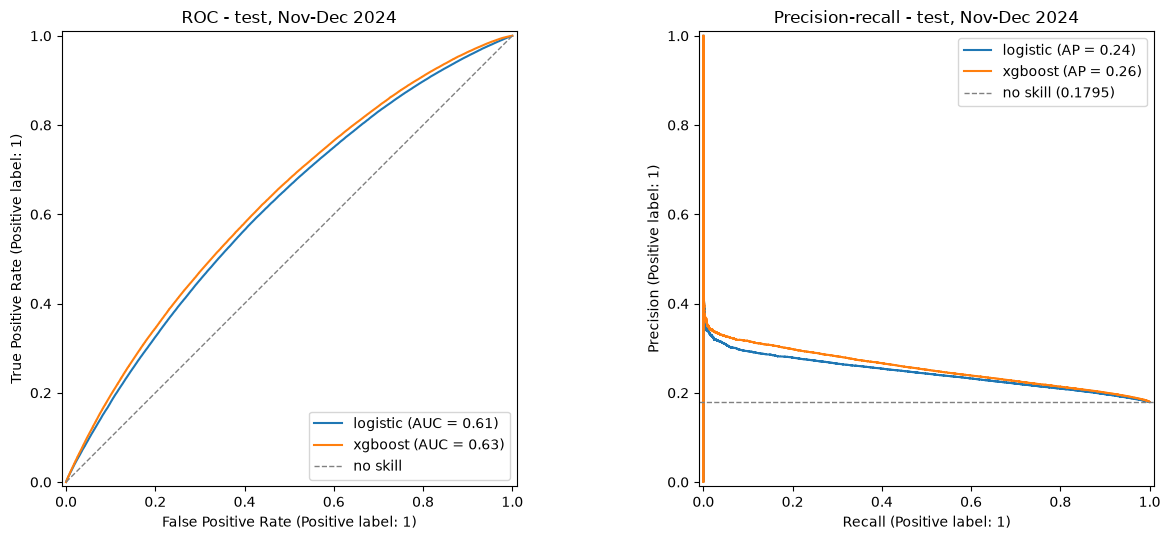

In [6]:
y_test = y[test]
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5.5))

for name, score in scores.items():
    RocCurveDisplay.from_predictions(y_test, score, name=name, ax=ax_roc)
    PrecisionRecallDisplay.from_predictions(y_test, score, name=name, ax=ax_pr)

ax_roc.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1, label="no skill")
ax_pr.axhline(
    y_test.mean(), color="grey", linestyle="--", linewidth=1,
    label=f"no skill ({y_test.mean():.4f})",
)

ax_roc.set_title("ROC - test, Nov-Dec 2024")
ax_pr.set_title("Precision-recall - test, Nov-Dec 2024")
for ax in (ax_roc, ax_pr):
    ax.legend(loc="lower right" if ax is ax_roc else "upper right")
fig.tight_layout()

FIGURES.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES / "roc_pr_xgboost.png", dpi=150)
plt.show()

## Feature importance

Gain = average loss reduction per split on that feature (not a sum, so a feature used rarely but well can rank high). Correlated features share the credit (e.g. `Distance` / `DistanceGroup`), so this is a hint, not an explanation.

Question: do the history features still dominate, or does the tree prefer raw `Origin` / `Dest`?

,gain
feature,
OriginHourHist,4651.866699
CRSDepTime,829.162598
DepHour,799.621399
Season,798.701111
RouteHist,785.181763
CRSArrTime,619.543457
Month,414.729889
Reporting_Airline,338.584106
CarrierHist,253.527557


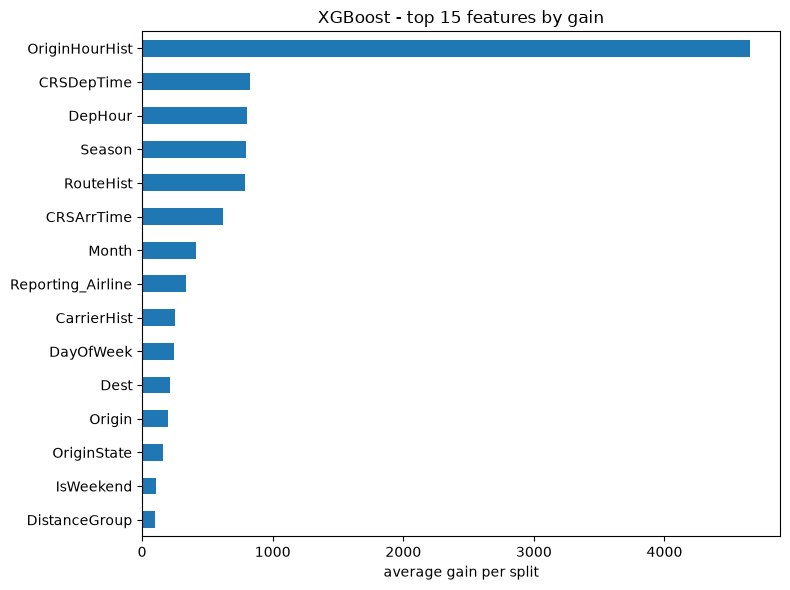

In [7]:
gain = G.feature_gain(model, list(X.columns))
display(gain)

ax = gain.head(15).iloc[::-1].plot.barh(legend=False, figsize=(8, 6))
ax.set_xlabel("average gain per split")
ax.set_ylabel("")
ax.set_title("XGBoost - top 15 features by gain")
plt.tight_layout()
plt.show()

## Save the model

`save_model` to JSON - XGBoost's own format, safer across versions than a pickle.

To do: the history features can't be computed for a single new flight at prediction time. Serving will need a separate table with history values as of a given day.

In [8]:
if not MODELS.exists():
    MODELS.mkdir(exist_ok=True)
model.save_model(MODELS / "xgboost.json")


## Ablation: XGBoost on the baseline's 12 columns

Same model, but only the columns logistic regression used (`LINEAR_NUMERIC + LINEAR_ONEHOT`). This separates "better model" from "8 more columns".

In [9]:
linear_cols = B.LINEAR_NUMERIC + B.LINEAR_ONEHOT
X_lin = X[linear_cols]

model_lin = G.make_model()
G.fit_with_early_stopping(model_lin, X_lin[fit], y[fit], X_lin[valid], y[valid])
print(model_lin.best_iteration, model_lin.best_score)

results["xgboost_12cols"] = E.evaluate_binary(y[test], model_lin.predict_proba(X_lin[test])[:, 1])
E.compare(results, decimals=5)

[0]	validation_0-aucpr:0.18485


[100]	validation_0-aucpr:0.21140


[164]	validation_0-aucpr:0.21129


114 0.2119990025015685


,roc_auc,pr_auc,no_skill_pr,precision,recall,f1,accuracy
logistic,0.61323,0.24498,0.17948,0.31920,0.02615,0.04834,0.81520
xgboost,0.62689,0.25572,0.17948,0.42857,0.00001,0.00003,0.82051
xgboost_12cols,0.62288,0.25078,0.17948,0.00000,0.00000,0.00000,0.82052


## What the numbers say

All numbers below are on the test months (Nov-Dec 2024, 1 156 765 flights, 17.95% delayed).
Both models learned from the same rows (Jan-Sep), October was used only to stop XGBoost.

| | ROC-AUC | PR-AUC | lift over no-skill |
|---|---|---|---|
| logistic (fit on Jan-Sep) | 0.6132 | 0.2450 | 1.36x |
| XGBoost | 0.6269 | 0.2557 | 1.42x |

**1. Did it clear the bar?** Yes, but only just. PR-AUC went from 0.245 to 0.256, about one
point. On the plots the two curves almost overlap, XGBoost sits slightly higher everywhere.
The cost side is small, though: early stopping kept only 120 trees (validation aucpr was
0.2148 at tree 100 and already falling to 0.2134 by tree 169), so training is quick and there
was no hyperparameter search at all. I keep XGBoost as the main model, but the honest summary
is that the model swap barely moved the needle. The ceiling is in the features: nothing here
knows about weather or what is happening at the airport on the day.

**2. Model or extra columns?** About half and half. XGBoost on only the baseline's 12 columns
gets PR-AUC 0.2508 (best iteration 114), so of the ~1.1 point gain over logistic regression
about 0.6 comes from the model itself and about 0.5 from the 8 extra columns. Which of the 8
columns do the work is not measured. The gain table hints at the time columns (`CRSDepTime`,
`CRSArrTime` near the top, raw `Origin` / `Dest` near the bottom), but gain is shared between
correlated columns (`Season` is just a coarser `Month`), so this is a guess, not a result.

**3. What would I actually ship?** Not the 0.5 threshold. XGBoost's highest score on the whole
test set is 0.52, so at 0.5 it flags 7 flights out of 1.16 million (recall 0.00001). The
useful way to read the model is as a ranking, and to flag the riskiest share of flights:

| flagged | precision | recall | score threshold |
|---|---|---|---|
| top 1% | 0.340 | 0.019 | 0.356 |
| top 5% | 0.318 | 0.089 | 0.293 |
| top 10% | 0.304 | 0.169 | 0.259 |
| top 20% | 0.280 | 0.312 | 0.216 |

With a top 10% watchlist, about 3 in 10 flagged flights are really late, against 1.8 in 10
for a random pick, and it catches about 17% of all delays. That is good enough to decide where
to look first (extra ground staff, earlier rebooking checks), not good enough to tell a
passenger "your flight will be late".

Side notes: the vertical spike at the left of the XGBoost PR curve is those few flights with
the highest scores (a handful of points, so precision jumps around), not a real effect. And
October, the validation month, had only 13.2% delays, so early stopping was tuned on the
easiest month of the year.